# Walking through Multi-head attention
First some recap:

Transformer models are encoder decoder models
* All inputs are entered together (no sequencing)
* They use “attention” to focus the model on key information
* They use “position encoding” to retain sequence information (since the entire input is entered in one go, we lose input ordering (Jack loves Jill is not the same as Jill loves Jack)

Let's see how the encoder process "Jack and Jill love Bill" through the attention module. We will
* Convert each word into a numerical token
* Then associate an embedding vector with each token
* Add position encoding to the vector
* Compute (fake) Query, Key, and Value vectors
* Compute the attention filter
* Pass Value through the attention filter

In [ ]:
#All necessary import
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization
from tensorflow.keras.layers import Embedding


In [ ]:
#Define our sentence and place it in a corpus of inputs (only one sentence in the corpus)
sentence = "Jack and Jill love Bill"
corpus = [sentence]

#Vectorize the sentence (associate numerical tokens with words in the sentence)
vectorize_layer = TextVectorization(max_tokens=8, #upper limit on the vocab size
                                    standardize='lower_and_strip_punctuation', # Lowercase text and remove punctuation
                                    split='whitespace', # Split sentence by whitespace
                                    output_mode='int', # Output as integers (one token per word)
                                    output_sequence_length=5) # length of each sentence (usually, sentences are padded to the same length)

#Build the vocabulary from words in the corpus
vectorize_layer.adapt(corpus)

#Print the size and the vocab
print(vectorize_layer.vocabulary_size()) # Number of unique tokens
print(vectorize_layer.get_vocabulary()) # List of tokens

#Print the token vector
encoding = vectorize_layer(corpus)
print(f"'{sentence}' -> {encoding[0]}")

vocab_size = vectorize_layer.vocabulary_size()

#Set the embedding dimension (the number of features for each token)
embedding_dim = 4

embedding = Embedding(input_dim=vocab_size, output_dim=embedding_dim)
embedded_sentence = embedding(vectorize_layer(corpus))
print(embedded_sentence)

7
['', '[UNK]', 'love', 'jill', 'jack', 'bill', 'and']
'Jack and Jill love Bill' -> [4 6 3 2 5]
tf.Tensor(
[[[-0.03161141 -0.02511836  0.00584134  0.00195347]
  [-0.01046972 -0.03331099  0.00825732  0.04317575]
  [-0.0392563  -0.02793322 -0.0494445  -0.04273042]
  [ 0.02097744 -0.03318546  0.01129939  0.01491914]
  [-0.02737336 -0.0094582   0.04386399 -0.04349574]]], shape=(1, 5, 4), dtype=float32)


When you call .get_vocabulary() on a TextVectorization layer, the vocabulary list always includes two special tokens at the start:

* `''` (Empty String): This is a placeholder for padding. If you pad sequences (to make them the same length), this token is used.
* `[UNK]` (Unknown Token): This token represents out-of-vocabulary (OOV) words.
Any word that doesn’t appear in the training data or exceeds max_tokens is replaced by `[UNK]`.

# Positional encoding
* Why Needed: Transformers process all words simultaneously, so positional encoding adds order information.
* How It Works:
Uses sine for even dimensions and cosine for odd dimensions.
The formula divides position by powers of 10,000 to create patterns that change gradually.
* Structure: Each word gets a 4-dimensional position vector that aligns with its embedding vector.

In [ ]:
#Define cos and sin functions
import math
def sine(pos,i,d):
  return math.sin(pos/(10000**((2*(i//2))/d)))

def cosine(pos,i,d):
  return math.cos(pos/(10000**((2*(i//2))/d)))



In [ ]:
#Calculate position vector values
import math
position_vector = np.zeros((5,4))
#Calculate position vectors
for pos in range(0,5):
  for i in range(0,4):
    if (i%2==0):
      position_vector[pos,i] = sine(pos,i,4)
    else:
      position_vector[pos,i] = cosine(pos,i,4)
position_vector

array([[ 0.        ,  1.        ,  0.        ,  1.        ],
       [ 0.84147098,  0.54030231,  0.00999983,  0.99995   ],
       [ 0.90929743, -0.41614684,  0.01999867,  0.99980001],
       [ 0.14112001, -0.9899925 ,  0.0299955 ,  0.99955003],
       [-0.7568025 , -0.65364362,  0.03998933,  0.99920011]])

# Visualize it
Notice for dimension 1 and 2, the change is quite dramatic whereas for dimension 3 and 4, the change is more subtle.

### Dimension 0 (Column 0, Sine):

Changes rapidly with each position (because of low frequency).
Helps capture local relationships (e.g., between adjacent words).

### Dimension 1 (Column 1, Cosine):

Also changes quickly but in a phase-shifted way (cosine leads sine by 90°).
Provides a complementary perspective to Dimension 0.

### Dimension 2 (Column 2, Sine):

Changes more slowly with position due to the division by a larger factor.
Helps capture longer-distance relationships.

### Dimension 3 (Column 3, Cosine):

Changes very slowly, staying close to 1 across all positions.
This slow change ensures that words far apart still have unique positional signatures.


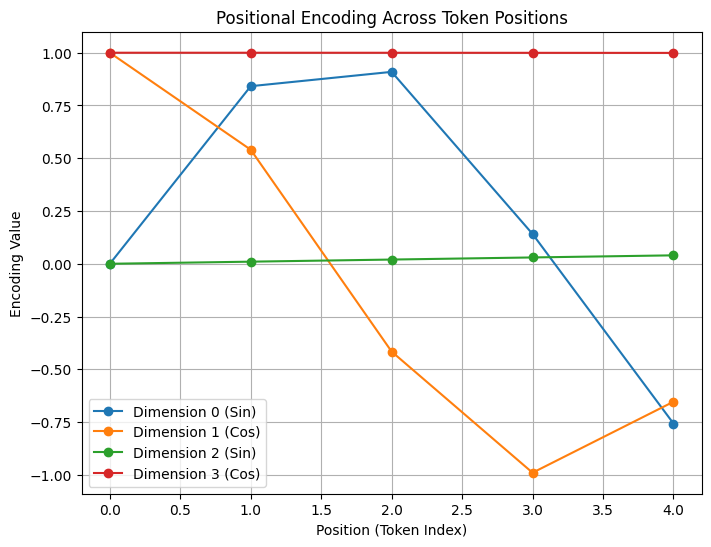

In [ ]:
import matplotlib.pyplot as plt
# Extract positions and dimensions
positions = np.arange(position_vector.shape[0])  # [0, 1, 2, 3, 4]
dim_labels = ['Dimension 0 (Sin)', 'Dimension 1 (Cos)', 'Dimension 2 (Sin)', 'Dimension 3 (Cos)']

# Plot each dimension
plt.figure(figsize=(8, 6))
for i in range(position_vector.shape[1]):
    plt.plot(positions, position_vector[:, i], marker='o', label=dim_labels[i])

plt.title('Positional Encoding Across Token Positions')
plt.xlabel('Position (Token Index)')
plt.ylabel('Encoding Value')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
position_vector2 = tf.round(position_vector.copy() * 100)/100
position_vector2

<tf.Tensor: shape=(5, 4), dtype=float64, numpy=
array([[ 0.  ,  1.  ,  0.  ,  1.  ],
       [ 0.84,  0.54,  0.01,  1.  ],
       [ 0.91, -0.42,  0.02,  1.  ],
       [ 0.14, -0.99,  0.03,  1.  ],
       [-0.76, -0.65,  0.04,  1.  ]])>

# Add input embedding and position encoding
* Addition keeps the final vector’s dimensionality the same as the embedded vector.
* Element-wise addition blends meaning and position into each dimension of the vector.

In [ ]:
input_embedding = embedded_sentence + position_vector
input_embedding

<tf.Tensor: shape=(1, 5, 4), dtype=float32, numpy=
array([[[-0.03161141,  0.97488165,  0.00584134,  1.0019535 ],
        [ 0.8310012 ,  0.50699127,  0.01825715,  1.0431257 ],
        [ 0.87004113, -0.44408005, -0.02944583,  0.95706964],
        [ 0.16209744, -1.023178  ,  0.0412949 ,  1.0144691 ],
        [-0.7841759 , -0.6631018 ,  0.08385332,  0.9557044 ]]],
      dtype=float32)>

# Query, Key, Value


* Each embedding vector is fed into each of the three linear layers
* The three layers represent Query, Key, and Value
* Query, key and value are motivated by search and retrieve systems
    * Query: A question - Ask a librarian to suggest books on a topic
    * Key: The list of books suggested by the librarian
    * Value: The content of each book
* Query, Key, Value require weights
* These are built through training
* We'll just create a random set of weights to use for our example

In [ ]:
query_weights = np.random.rand(4,4) # same dimension as our embedding because we are doing a scaled dot product
key_weights = np.random.rand(4,4)
value_weights = np.random.rand(4,4)

In [ ]:
query = np.dot(input_embedding[0], query_weights)
key = np.dot(input_embedding[0], key_weights)
value = np.dot(input_embedding[0], value_weights)
print(query)
print(key)
print(value)

[[ 1.3798375   0.78267102  1.12680608  0.99595557]
 [ 1.70166182  0.79755547  1.39368201  1.22886927]
 [ 1.08776988  0.57432061  1.03276924  0.68526239]
 [ 0.41734779  0.51763736  0.67981074  0.01427858]
 [ 0.00563034  0.50041048  0.37330123 -0.32864366]]
[[ 0.75441439  1.24051595  0.38968352  1.54534214]
 [ 0.95316393  1.59390706  0.74749455  1.81722527]
 [ 0.84468235  0.73364244  0.68629517  0.91248598]
 [ 0.70773005 -0.33354223  0.43744672 -0.03162015]
 [ 0.48013258 -0.8374932   0.06029342 -0.43122226]]
[[ 1.12160883  0.66029406  0.61516015  1.30971206]
 [ 1.15917814  0.9991015   1.31346234  1.78190027]
 [ 0.8814659   0.49621943  0.9961368   1.15233909]
 [ 0.85246159 -0.23505076  0.19031748  0.2966199 ]
 [ 0.82325485 -0.66632008 -0.59959443 -0.2935309 ]]


# Attention filter

In [ ]:
query.shape, key.shape, value.shape

((5, 4), (5, 4), (5, 4))

In [ ]:
np.dot(query,key.T)/np.sqrt(4)


array([[ 1.99503751,  2.60743662,  1.71092106,  0.588462  , -0.17725797],
       [ 2.35762841,  3.08404698,  2.05014372,  0.75455169, -0.14840497],
       [ 1.49725057,  1.98475111,  1.33712143,  0.50420034, -0.09597353],
       [ 0.62198346,  0.87848446,  0.60593344,  0.20982257, -0.09915231],
       [ 0.13130862,  0.24239776,  0.16409516,  0.00538395, -0.1260805 ]])

The product of Q and K is passed through a softmax function (all values are now between 0 and 1). This is the attention filter a n x n matrix

Remember n is for tokens and m for embedding


In [ ]:
def softmax(x):
    x = x - np.max(x, axis=1, keepdims=True)
    return np.exp(x) / np.sum(np.exp(x), axis=1, keepdims=True)

attention_filter = softmax(np.dot(query,key.T)/np.sqrt(4))
print(attention_filter)

[[0.19077645 0.44503405 0.26951746 0.06878158 0.02589046]
 [0.18495239 0.48131519 0.26111988 0.05442923 0.01818331]
 [0.20281784 0.3754628  0.2670889  0.10308271 0.05154775]
 [0.183003   0.22336486 0.23394645 0.19836714 0.16131854]
 [0.15936796 0.16666002 0.20665321 0.23742885 0.22988996]]


# Compute value
* Now we have an attention filter and a Value matrix
* The Value matrix is (mostly) the original input with position encoding
* Though, as it is passed through a Value weight matrix, the attention filter filters this Value matrix with the purpose of underweighting unnecessary stuff and overweighting necessary stuff
* The filtered value matrix is the output of the multi-head attention layer == Dot product of the attention filter and V

In [ ]:
attention_filter.shape, value.shape

((5, 5), (5, 4))

In [ ]:
np.dot(value.T,attention_filter).T

array([[ 1.79221233,  0.80711689,  0.96572884,  1.42063527],
       [ 2.48929268,  1.21773457,  1.32709462,  1.97819657],
       [ 0.68460574,  0.11090193,  0.39835077,  0.50446564],
       [ 0.22216815, -0.10464699,  0.15035148,  0.13729994],
       [ 0.16784386, -0.1104548 ,  0.11828763,  0.09842571]])

# Masked Attention
* The masked attention unit in the decoder pays attention only to prior tokens, not to future ones
* In essence, the transformer is not paying attention to later tokens, only previous ones
* Future values are set to -inf by the following process

In [ ]:
np.dot(query,key.T)
mask=np.zeros((5,5))
upper_indices = np.triu_indices(mask.shape[0], 1)

mask[upper_indices]=-np.inf
mask

array([[  0., -inf, -inf, -inf, -inf],
       [  0.,   0., -inf, -inf, -inf],
       [  0.,   0.,   0., -inf, -inf],
       [  0.,   0.,   0.,   0., -inf],
       [  0.,   0.,   0.,   0.,   0.]])

In [ ]:
np.dot(query,key.T)/np.sqrt(4) + mask

array([[ 1.42780551,        -inf,        -inf,        -inf,        -inf],
       [ 2.55283311,  2.94324108,        -inf,        -inf,        -inf],
       [ 2.31530648,  2.68439839,  1.15625811,        -inf,        -inf],
       [ 1.31935695,  1.56659692,  0.72506886, -0.16538587,        -inf],
       [ 0.20901854,  0.30326045,  0.20885162,  0.05798746, -0.03840407]])

In [ ]:
m_attention_filter = softmax(np.dot(query,key.T)/np.sqrt(4) + mask)
m_attention_filter

array([[1.        , 0.        , 0.        , 0.        , 0.        ],
       [0.40361909, 0.59638091, 0.        , 0.        , 0.        ],
       [0.36229191, 0.52402645, 0.11368164, 0.        , 0.        ],
       [0.32690397, 0.41859607, 0.1804364 , 0.07406356, 0.        ],
       [0.21100206, 0.23185445, 0.21096684, 0.181424  , 0.16475265]])

In [ ]:
np.dot(value.T,m_attention_filter)

array([[ 2.62173056,  1.21111943,  0.26349719,  0.13744173,  0.12216837],
       [ 1.11447913,  0.99670042,  0.15039228, -0.09807434, -0.15462442],
       [ 3.33928407,  1.90371912,  0.29679554, -0.02327676, -0.0702585 ],
       [ 2.25456568,  1.5165842 ,  0.43131003,  0.16179259,  0.07327933]])

# Position encoding
* Each position corresponds to a vector of the same dimension as the embedding
* Since the value at each position is a function of the index in the embedding vector, think of each embedding dimension as representing a sine (or cosine) wave at a different amplitude
* Sine and Cosine functions are wave functions and can be plotted at different amplitudes as below


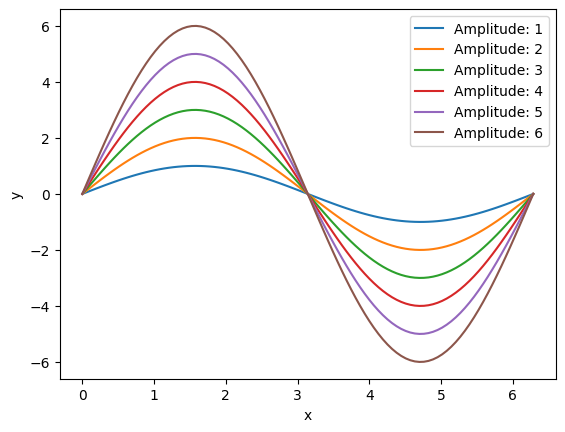

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define x-axis values
x = np.linspace(0, 2*np.pi, 100)

# Different amplitudes for sine waves
amplitudes = [1, 2, 3, 4, 5, 6]

# Plot each sine wave with different amplitudes
for amp in amplitudes:
    y = amp * np.sin(x)
    plt.plot(x, y, label=f"Amplitude: {amp}")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

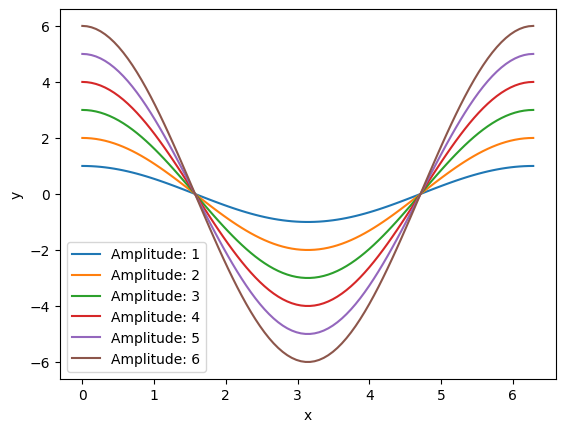

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define x-axis values
x = np.linspace(0, 2*np.pi, 100)

# Different amplitudes for sine waves
amplitudes = [1, 2, 3, 4, 5, 6]

# Plot each sine wave with different amplitudes
for amp in amplitudes:
    y = amp * np.cos(x)
    plt.plot(x, y, label=f"Amplitude: {amp}")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

* Though, in position encoding, the waves are all normalized to between -1 and 1, the amplitude is represented by the scaling factor (the value being multiplied by pos
* Let's look at this factor

In [ ]:
#Define cos and sin functions
import math
def scaling(pos,i,d):
  scaling_factor = 1/(10000**((2*(i//2))/d))
  print(pos, i, scaling_factor, math.sin(pos*scaling_factor))



In [ ]:
scaling(1,0,4)

1 0 1.0 0.8414709848078965


In [ ]:
scaling(1,1,4)

1 1 1.0 0.8414709848078965


In [ ]:
scaling(1,2,4)

1 2 0.01 0.009999833334166664


In [ ]:
scaling(1,3,4)

1 3 0.01 0.009999833334166664


In [ ]:
scaling(1,4,4)

1 4 0.0001 9.999999983333334e-05


* For lower dimensions (low values of i) the scaling factor is larger, thus the value varies a lot as the value of pos (the position of the token in the sequence) changes
* For higher dimensions (high values of i) the scaling factor is smaller, thus the value is reasonably stable as pos changes
* We can see this in the following example

In [ ]:
#Calculate position vector values
import math
position_vector = np.zeros((8,9))
#Calculate position vectors
for pos in range(0,8):
  for i in range(0,9):
    if (i%2==0):
      position_vector[pos,i] = sine(pos,i,9)
    else:
      position_vector[pos,i] = cosine(pos,i,9)
tf.round(position_vector.copy() * 100)/100

<tf.Tensor: shape=(8, 9), dtype=float64, numpy=
array([[ 0.  ,  1.  ,  0.  ,  1.  ,  0.  ,  1.  ,  0.  ,  1.  ,  0.  ],
       [ 0.84,  0.54,  0.13,  0.99,  0.02,  1.  ,  0.  ,  1.  ,  0.  ],
       [ 0.91, -0.42,  0.26,  0.97,  0.03,  1.  ,  0.  ,  1.  ,  0.  ],
       [ 0.14, -0.99,  0.38,  0.93,  0.05,  1.  ,  0.01,  1.  ,  0.  ],
       [-0.76, -0.65,  0.49,  0.87,  0.07,  1.  ,  0.01,  1.  ,  0.  ],
       [-0.96,  0.28,  0.6 ,  0.8 ,  0.08,  1.  ,  0.01,  1.  ,  0.  ],
       [-0.28,  0.96,  0.7 ,  0.71,  0.1 ,  0.99,  0.01,  1.  ,  0.  ],
       [ 0.66,  0.75,  0.79,  0.62,  0.12,  0.99,  0.02,  1.  ,  0.  ]])>

* Another way of looking at this is by considering the frequency of the waves
** when i is small, the freqency of the wave is low and the wavelength is large. So small changes in pos result in big changes in sine value
** when i is large, the frequency is high and the wave length is small. So, small changes in pos result in small changes in sine value

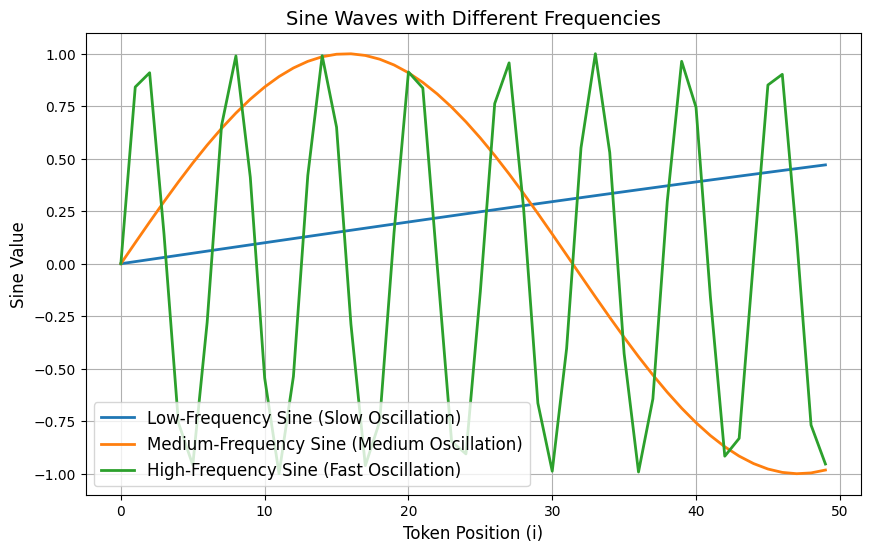

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate positions
positions = np.arange(0, 50, 1)  # 50 positions

# Define low-frequency and high-frequency scaling factors
low_freq_factor = 100  # For slow oscillation
med_freq_factor = 10  # For medium oscillation
high_freq_factor = 1   # For fast oscillation

# Compute sine values
low_freq_sine = np.sin(positions / low_freq_factor)
med_freq_sine = np.sin(positions / med_freq_factor)
high_freq_sine = np.sin(positions / high_freq_factor)

# Plot the sine waves
plt.figure(figsize=(10, 6))

# Low frequency
plt.plot(positions, low_freq_sine, label="Low-Frequency Sine (Slow Oscillation)", linewidth=2)

# Med frequency
plt.plot(positions, med_freq_sine, label="Medium-Frequency Sine (Medium Oscillation)", linewidth=2)

# High frequency
plt.plot(positions, high_freq_sine, label="High-Frequency Sine (Fast Oscillation)", linewidth=2)

# Formatting the plot
plt.title("Sine Waves with Different Frequencies", fontsize=14)
plt.xlabel("Token Position (i)", fontsize=12)
plt.ylabel("Sine Value", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

# Intuition (the why)
* the slow oscillating waves (lower i) can capture long term position information (e.g., the subject usually comes early in the sentence)
* the fast oscillating waves (higher i) can capture short term relationships (e.g., "candle light")


# Why sine and cosine
* The authors of the paper say
* *We chose this function because we hypothesized it would allow the model to easily learn to attend by relative positions, since for any fixed offset k, PEpos+k can be represented as a linear function of PEpos.*
* If you're interested in figuring this out a good explanation and proof is at https://blog.timodenk.com/linear-relationships-in-the-transformers-positional-encoding/